# Visualization: Session 4 (January 27, 2026)

Slide Deck 7: Accessibility
- Overview of this slide deck, we will...
- Discuss the real-world impacts of inaccessible data visualization
- Explore practical tips and resources that we can use to improve the accessibility of our data visualizations, especially relating to:
    - Colour
    - Text
    - Image Descriptions
    - Getting our visualizations to the intended audiences


Slide Deck 6: Learn about subplot notation in matplotlib
- Put multiple visualizations on the same axes objects
- Show errors
- Adjust figure layout
- Add images to plots


## Recall: How does matplotlib work?
- A figure is like a container that holds a set of axes
- The axes is our actual plot or graph
- A figure can hold multiple axes (like subplots)
- Every visual element of our plots – colour, legends, axis titles and scales, text – is called an artist and belongs to an axes (not to a figure)

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

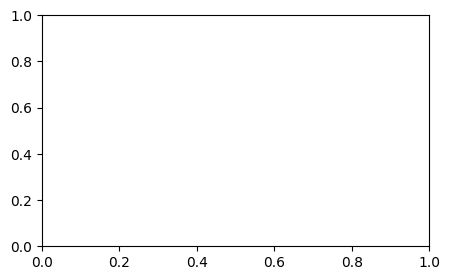

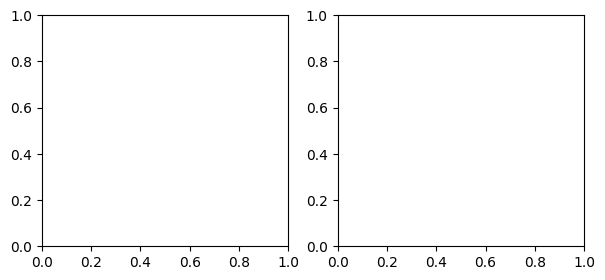

In [71]:
#What we were doing before (figure and its one axes):

fig, ax = plt.subplots(figsize=(5, 3))

#Now we want to have two plots next to each other, so we just have to define multiple axes and their relative positions:
fig,(ax1, ax2) = plt.subplots(ncols=2,
nrows=1,
figsize=(7, 3))

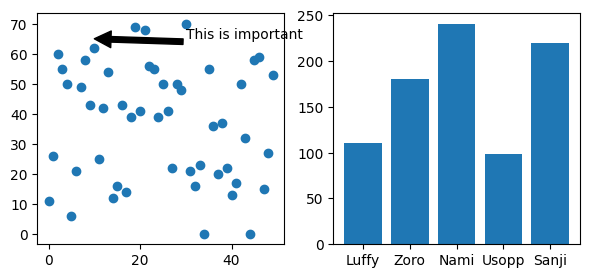

In [72]:
#Then we can use our new figure, with its two axes, and define the types of viz that we want to see in each
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    nrows=1,
    figsize=(7, 3)
)

ax1.scatter(x1, y1)
ax1.annotate(
    'This is important',
    xy=(10, 65),
    xytext=(30, 65),
    arrowprops=dict(facecolor='black')
)

ax2.bar(x2, y2)

plt.show()


# Activity: Customizing our plots

- Refer to past slides and class activities to customize the subplots we just made
- Think about adding titles or annotations, or modifying colour, marker type, and fonts – differently for each subplot
- Share your resulting images in the chat!

(see above)

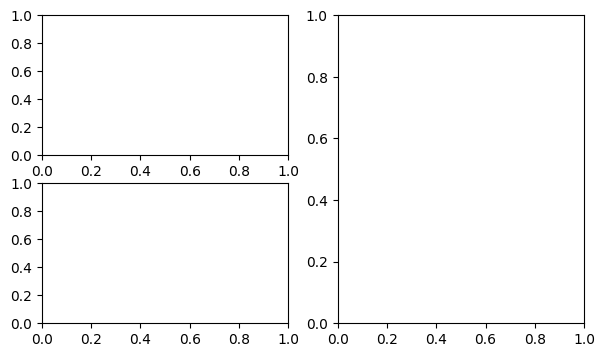

In [73]:
# Subplots without a grid arrangement?

fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
['ax2', 'ax3']],
figsize=(7, 4))


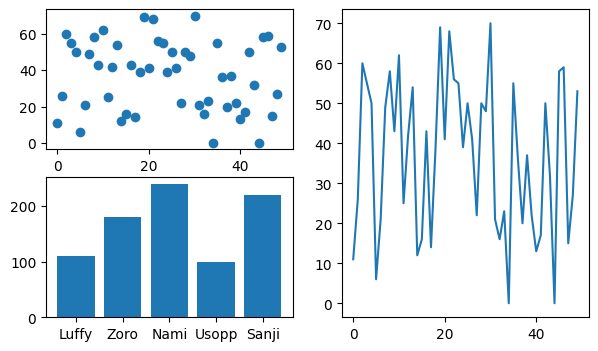

In [74]:
# Once we’ve made our mosaic, we can add data to each of our subplots the same way we did before! Just reference each axes label in our someaxes list:

fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
['ax2', 'ax3']],
figsize=(7, 4))
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
plt.show()

# Layouts

Let’s try adding some very large x axis titles to our previous plot:

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

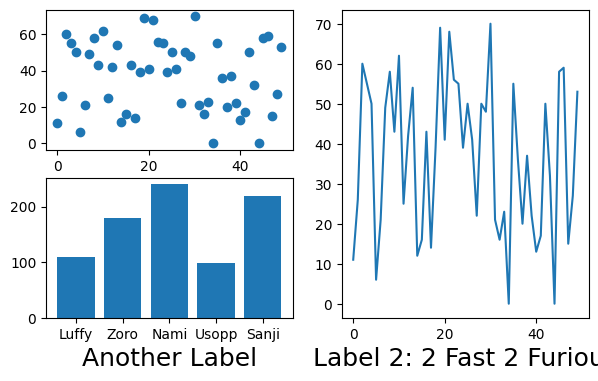

In [75]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
['ax2', 'ax3']],
figsize=(7, 4))
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

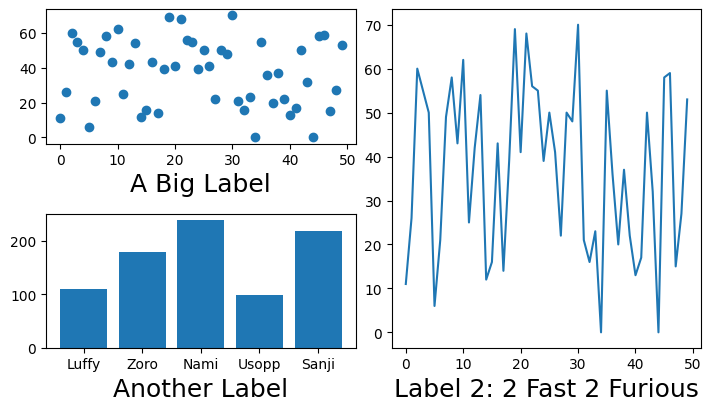

In [76]:
# constrained layout

fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
['ax2', 'ax3']],
figsize=(7, 4),
layout = "constrained")
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious', fontsize=18)

# Multiple viz on one axes object

Call multiple plot methods on the same axes

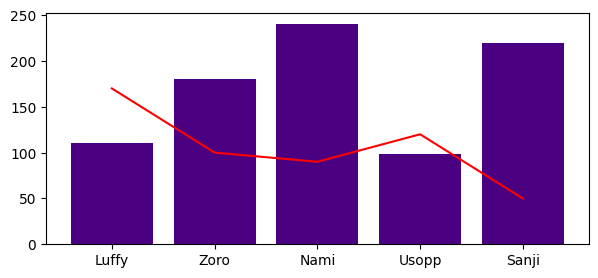

In [77]:
# first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])
# define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))
# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,
color = "indigo")
ax.plot(x, y2,
color = "red")

<ErrorbarContainer object of 3 artists>

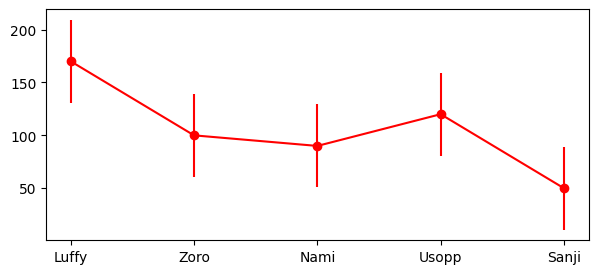

In [78]:
# Adding more features

# 1. Adding error information
y2_sd = np.std(y2)

# 2. Then plot our line as before
fig, ax = plt.subplots(figsize=(7, 3))
#ax.plot(x, y2, color = "red")
ax.errorbar(x,y2,color='red',yerr=y2_sd, fmt='o-')

<ErrorbarContainer object of 3 artists>

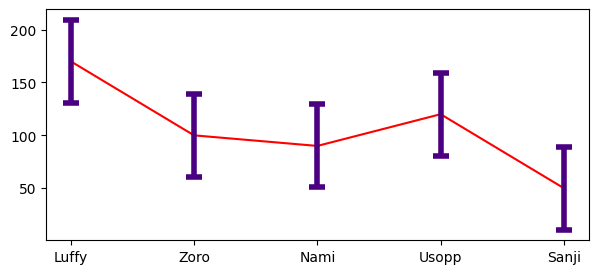

In [79]:
#Customizing errorbar appearance
Fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
color = "red")
ax.errorbar(x,
y2,
yerr = y2_sd,
fmt = "none",
ecolor= "indigo",
elinewidth= 4,
capsize = 6,
capthick= 4 )

<ErrorbarContainer object of 3 artists>

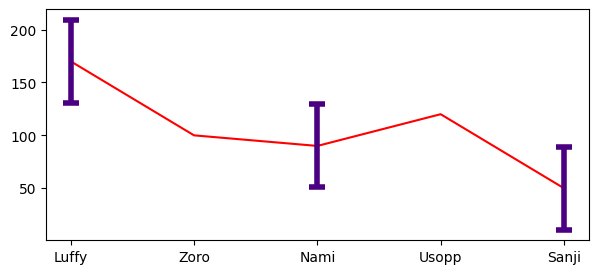

In [80]:
# Errorevery --> If we don’t want to see error bars for every single point, we can specify intervals using errorevery

Fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
color = "red")
ax.errorbar(x,
y2,
yerr = y2_sd,
fmt = "none",
ecolor = "indigo",
elinewidth = 4,
capsize = 6,
capthick = 4,
errorevery= 2 )

# Adding Images (session slides completed during session 5)

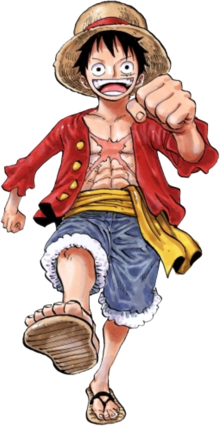

In [81]:
from PIL import Image
import requests
from io import BytesIO

url = 'https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png'

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()  # good practice

image_file = BytesIO(response.content)
image = Image.open(image_file)

image

image


# Adding an image to a plot

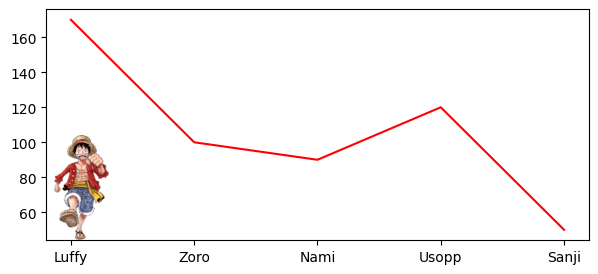

In [82]:
# Now make a basic line plot (reusing our data):
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

# Then overlay a new axis (‘ax_image’) on our figure
# (coordinates are on the FIGURE, not the data axes)
ax_image = fig.add_axes([
    0.10,  # x position
    0.11,  # y position
    0.15,  # width
    0.35   # height
])

# Show the image in the new axes
ax_image.imshow(image)
ax_image.axis('off')  # hide ticks and frame

plt.show()


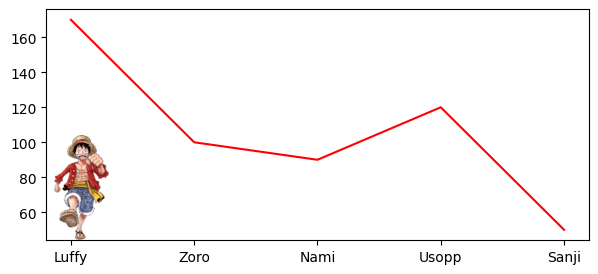

In [83]:
# Then add imshow() to add the image we prepared before

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35])
ax_image.imshow(image)
ax_image.axis('off')

plt.show()


# Saving our visualizations

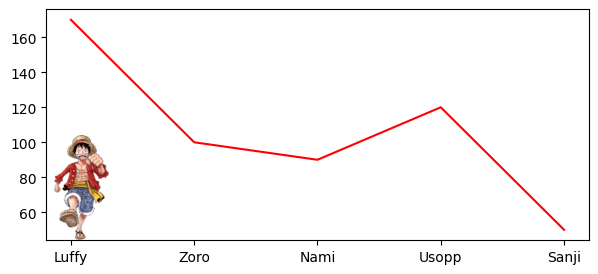

In [84]:
# Then add imshow() to add the image we prepared before

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35])
ax_image.imshow(image)
ax_image.axis('off')

path = 'C:/Users/...'
# can be full path or relative path
filename = './fig1a.png'

plt.savefig(filename, dpi=300)
# note that path shouldn't end with / since filename starts with it